In [11]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

import statsmodels.api as sm

import matplotlib.pyplot as plt


In [12]:
CSV_FILE = "Temperature_Pressure_FuelRate.csv"

df = pd.read_csv(CSV_FILE)
df


,Temperature,Pressure,Fuel Rate
0,282.00,31.46,16.62
1,253.81,35.94,18.35
2,257.82,30.41,17.70
3,274.90,40.91,17.30
4,291.79,33.11,15.97
5,295.40,37.95,15.97
6,303.78,33.74,15.67
7,260.14,36.24,18.10
8,271.62,36.56,17.30
9,265.11,32.22,17.62


In [13]:
corr = df.corr(numeric_only=True)
corr


,Temperature,Pressure,Fuel Rate
Temperature,1.000000,0.050855,-0.966125
Pressure,0.050855,1.000000,0.154204
Fuel Rate,-0.966125,0.154204,1.000000


In [14]:
target = "Temperature"
candidates = [c for c in df.columns if c != target]
best_feature = max(candidates, key=lambda c: abs(corr.loc[target, c]))
best_feature, corr.loc[target, best_feature]


('Fuel Rate', np.float64(-0.9661245301027146))

In [15]:
X = df[["Fuel Rate", "Pressure"]]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((32, 2), (8, 2))

In [16]:
X1_train = X_train[[best_feature]]
X1_test = X_test[[best_feature]]

uni_model = LinearRegression()
uni_model.fit(X1_train, y_train)

y_pred_uni = uni_model.predict(X1_test)

r2_uni = r2_score(y_test, y_pred_uni)
mse_uni = mean_squared_error(y_test, y_pred_uni)
rmse_uni = np.sqrt(mse_uni)

print("Univariate feature:", best_feature)
print("Intercept (a):", uni_model.intercept_)
print("Slope (b):", uni_model.coef_[0])
print("R^2:", r2_uni)
print("MSE:", mse_uni)
print("RMSE:", rmse_uni)


Univariate feature: Fuel Rate
Intercept (a): 604.0925785938459
Slope (b): -19.201812969584324
R^2: 0.6426144551155789
MSE: 48.90411025989053
RMSE: 6.993147378676538


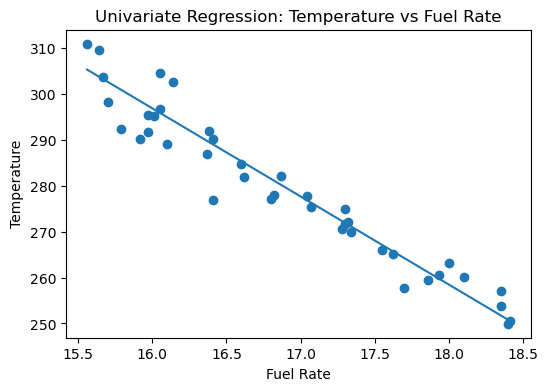

In [17]:
plt.figure(figsize=(6,4))
plt.scatter(df[best_feature], df[target])
x_line = np.linspace(df[best_feature].min(), df[best_feature].max(), 100)
y_line = uni_model.intercept_ + uni_model.coef_[0] * x_line
plt.plot(x_line, y_line)
plt.xlabel(best_feature)
plt.ylabel(target)
plt.title(f"Univariate Regression: {target} vs {best_feature}")
plt.show()

In [18]:
multi_model = LinearRegression()
multi_model.fit(X_train, y_train)

y_pred_multi = multi_model.predict(X_test)

r2_multi = r2_score(y_test, y_pred_multi)
mse_multi = mean_squared_error(y_test, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)

print("Intercept (a):", multi_model.intercept_)
for name, coef in zip(X.columns, multi_model.coef_):
    print(f"Coefficient for {name}: {coef}")
print("R^2:", r2_multi)
print("MSE:", mse_multi)
print("RMSE:", rmse_multi)

Intercept (a): 580.3358962795186
Coefficient for Fuel Rate: -19.311448158431574
Coefficient for Pressure: 0.715557761376112
R^2: 0.857408032175735
MSE: 19.512074331119912
RMSE: 4.417247370378968


In [19]:
X_sm = sm.add_constant(df[["Fuel Rate", "Pressure"]])
ols_model = sm.OLS(df[target], X_sm).fit()
print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:            Temperature   R-squared:                       0.974
Model:                            OLS   Adj. R-squared:                  0.973
Method:                 Least Squares   F-statistic:                     701.4
Date:                Sat, 28 Feb 2026   Prob (F-statistic):           3.83e-30
Time:                        23:23:00   Log-Likelihood:                -96.157
No. Observations:                  40   AIC:                             198.3
Df Residuals:                      37   BIC:                             203.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        568.1301      8.963     63.388      0.0

In [20]:
results = pd.DataFrame({
    "Model": [f"Univariate ({best_feature})", "Multivariate (Fuel Rate + Pressure)"],
    "R^2": [r2_uni, r2_multi],
    "MSE": [mse_uni, mse_multi],
    "RMSE": [rmse_uni, rmse_multi]
})
results

,Model,R^2,MSE,RMSE
0,Univariate (Fuel Rate),0.642614,48.904110,6.993147
1,Multivariate (Fuel Rate + Pressure),0.857408,19.512074,4.417247
